In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


DATASET LOADED
Shape: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  defa

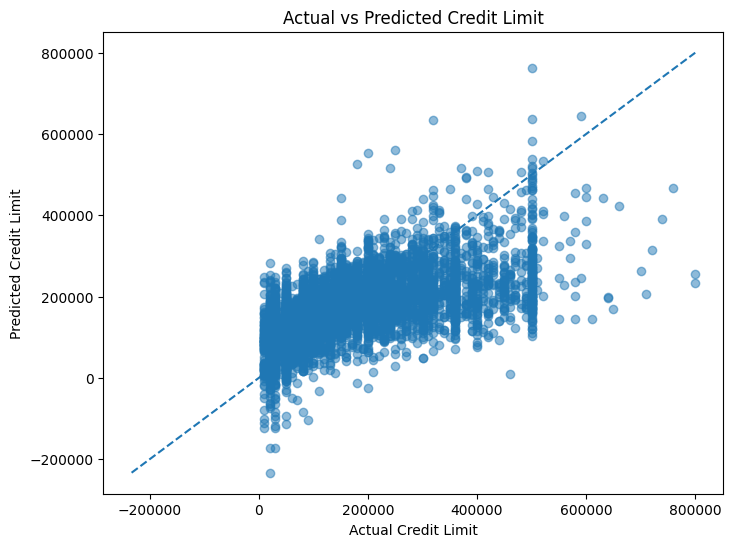

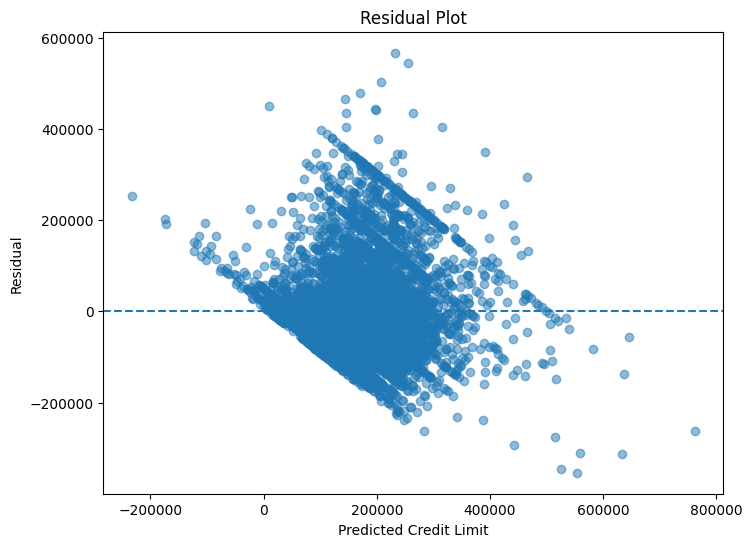


FEATURE COEFFICIENTS
                   Feature   Coefficient  Absolute_Coefficient
               EDUCATION_6 -78882.057376          78882.057376
           AGE_GROUP_Older -66877.928946          66877.928946
               EDUCATION_3 -59217.938640          59217.938640
               EDUCATION_5 -54772.537350          54772.537350
           AGE_GROUP_Young -47359.320849          47359.320849
                MARRIAGE_3 -43708.646009          43708.646009
          AGE_GROUP_Senior -42774.217152          42774.217152
               EDUCATION_2 -37772.872660          37772.872660
                 BILL_AMT1  27527.002105          27527.002105
      NUM_DELAYED_PAYMENTS  24314.903720          24314.903720
                       AGE  22182.891457          22182.891457
                     PAY_2 -17264.860998          17264.860998
                 BILL_AMT5  15508.337060          15508.337060
                     PAY_0 -13013.300606          13013.300606
      AGE_GROUP_Middle_Age -11761

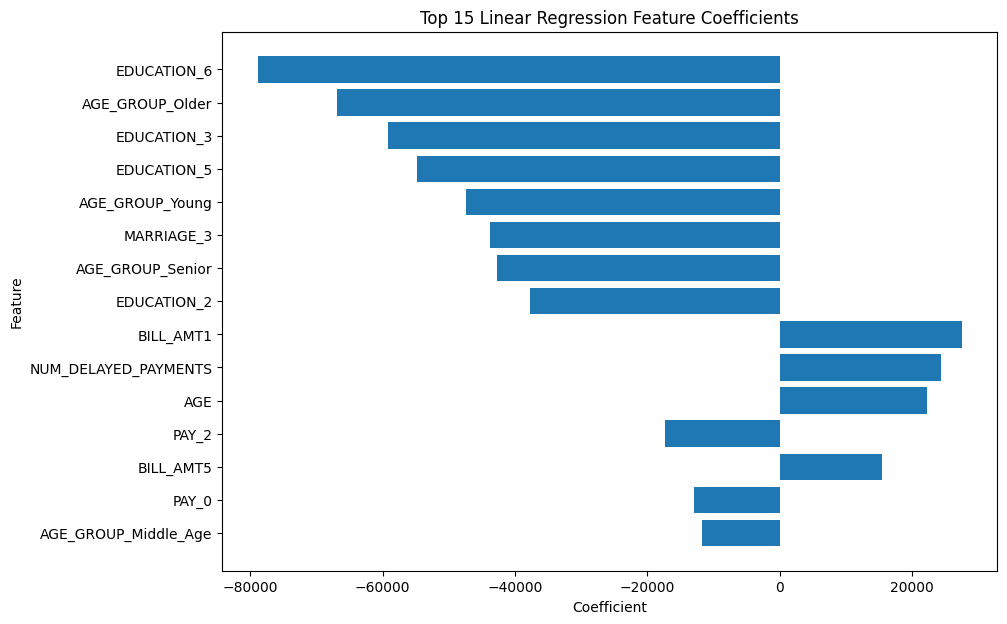


SAMPLE PREDICTIONS
   Actual_LIMIT_BAL  Predicted_LIMIT_BAL
0           30000.0         38829.284490
1          150000.0        210809.318441
2           70000.0        142410.316632
3          130000.0        102390.268364
4           50000.0        116631.311614
5           50000.0        136789.135851
6          110000.0         67591.975911
7          140000.0        249278.174135
8          260000.0        138036.995331
9           80000.0        120671.211503

SINGLE CUSTOMER PREDICTION
Actual Credit Limit: 30000.0
Predicted Credit Limit: 38829.28

PROJECT SUMMARY
Target Variable       : LIMIT_BAL
Algorithm             : Linear Regression
Feature Scaling       : StandardScaler
Categorical Encoding  : OneHotEncoder
Train/Test Split      : 80/20
MAE                   : 76995.2
MSE                   : 10280440387.47
RMSE                  : 101392.51
R² Score              : 0.3898

Project completed successfully!


In [ ]:

# LINEAR REGRESSION, FEATURE SCALING AND ENCODING PROJECT
# Dataset: UCI_Credit_Card.csv

# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -------------------- 2. LOAD DATASET ------------------------

df = pd.read_csv("UCI_Credit_Card.csv")

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())


# -------------------- 3. BASIC EDA ----------------------------

print("\n" + "=" * 60)
print("BASIC EDA")
print("=" * 60)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


# -------------------- 4. REMOVE DUPLICATES --------------------

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


# -------------------- 5. DEFINE TARGET ------------------------

# LIMIT_BAL is a continuous numerical variable.
# Therefore, it is suitable for Linear Regression.

target = "LIMIT_BAL"

y = df[target]

# We remove LIMIT_BAL from input features because it is our target.
X = df.drop(columns=[target])


# -------------------- 6. FEATURE ENGINEERING ------------------

# Total bill amount
df["TOTAL_BILL_AMT"] = (
    df["BILL_AMT1"] +
    df["BILL_AMT2"] +
    df["BILL_AMT3"] +
    df["BILL_AMT4"] +
    df["BILL_AMT5"] +
    df["BILL_AMT6"]
)

# Average bill amount
df["AVG_BILL_AMT"] = df[
    ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
     "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
].mean(axis=1)

# Total payment amount
df["TOTAL_PAYMENT_AMT"] = (
    df["PAY_AMT1"] +
    df["PAY_AMT2"] +
    df["PAY_AMT3"] +
    df["PAY_AMT4"] +
    df["PAY_AMT5"] +
    df["PAY_AMT6"]
)

# Average payment amount
df["AVG_PAYMENT_AMT"] = df[
    ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
     "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
].mean(axis=1)

# Payment-to-bill ratio
df["PAYMENT_BILL_RATIO"] = (
    df["TOTAL_PAYMENT_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)

# Average repayment status
df["AVG_REPAYMENT_STATUS"] = df[
    ["PAY_0", "PAY_2", "PAY_3",
     "PAY_4", "PAY_5", "PAY_6"]
].mean(axis=1)

# Number of delayed payments
df["NUM_DELAYED_PAYMENTS"] = (
    df[
        ["PAY_0", "PAY_2", "PAY_3",
         "PAY_4", "PAY_5", "PAY_6"]
    ] > 0
).sum(axis=1)


# -------------------- 7. CREATE AGE GROUP ---------------------

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["Young", "Adult", "Middle_Age", "Senior", "Older"]
)


# -------------------- 8. UPDATE X AND Y ------------------------

y = df["LIMIT_BAL"]

X = df.drop(columns=["LIMIT_BAL"])


# -------------------- 9. HANDLE INF / MISSING VALUES ----------

X = X.replace([np.inf, -np.inf], np.nan)

# Remove rows containing missing values
valid_rows = X.notnull().all(axis=1)

X = X.loc[valid_rows]
y = y.loc[valid_rows]

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)


# -------------------- 10. IDENTIFY COLUMN TYPES ---------------

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE_GROUP"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# -------------------- 11. FEATURE SCALING + ENCODING -----------

# StandardScaler:
# Converts numerical features approximately to:
# mean = 0
# standard deviation = 1

# OneHotEncoder:
# Converts categorical values into numerical 0/1 columns.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# -------------------- 12. TRAIN TEST SPLIT ---------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# -------------------- 13. CREATE LINEAR REGRESSION PIPELINE ----

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


# -------------------- 14. TRAIN MODEL --------------------------

model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully!")


# -------------------- 15. MAKE PREDICTIONS ---------------------

y_pred = model.predict(X_test)


# -------------------- 16. MODEL EVALUATION ---------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))


# -------------------- 17. ACTUAL VS PREDICTED ------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Credit Limit")
plt.ylabel("Predicted Credit Limit")
plt.title("Actual vs Predicted Credit Limit")

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()


# -------------------- 18. RESIDUAL PLOT ------------------------

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Credit Limit")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()


# -------------------- 19. GET FEATURE NAMES ---------------------

# Get the fitted preprocessor
fitted_preprocessor = model.named_steps["preprocessor"]

# Numerical feature names
numerical_names = numerical_features

# Get encoded categorical feature names
encoded_names = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

# Combine all feature names
feature_names = np.concatenate(
    [numerical_names, encoded_names]
)


# -------------------- 20. GET MODEL COEFFICIENTS ----------------

coefficients = model.named_steps["regressor"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)


print("\n" + "=" * 60)
print("FEATURE COEFFICIENTS")
print("=" * 60)

print(coefficient_df.to_string(index=False))


# -------------------- 21. TOP FEATURE COEFFICIENTS --------------

top_features = coefficient_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Linear Regression Feature Coefficients")

plt.gca().invert_yaxis()

plt.show()


# -------------------- 22. SAMPLE PREDICTIONS -------------------

results = pd.DataFrame({
    "Actual_LIMIT_BAL": y_test.values,
    "Predicted_LIMIT_BAL": y_pred
})

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

print(results.head(10))


# -------------------- 23. PREDICT A SINGLE CUSTOMER ------------

single_customer = X_test.iloc[[0]]

single_prediction = model.predict(single_customer)

print("\n" + "=" * 60)
print("SINGLE CUSTOMER PREDICTION")
print("=" * 60)

print("Actual Credit Limit:",
      y_test.iloc[0])

print("Predicted Credit Limit:",
      round(single_prediction[0], 2))


# -------------------- 24. FINAL SUMMARY ------------------------

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("Target Variable       : LIMIT_BAL")
print("Algorithm             : Linear Regression")
print("Feature Scaling       : StandardScaler")
print("Categorical Encoding  : OneHotEncoder")
print("Train/Test Split      : 80/20")
print("MAE                   :", round(mae, 2))
print("MSE                   :", round(mse, 2))
print("RMSE                  :", round(rmse, 2))
print("R² Score              :", round(r2, 4))

print("\nProject completed successfully!")